<a href="https://colab.research.google.com/github/nyp-sit/iti121-2025s2/blob/main/L9/timeseries_classification_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Timeseries classification using RNN

## Introduction

In this lab exercise, we will apply a simple RNN using PyTorch to do timeseries classification.

*The lab is adapted from the example codes on keras.io*

In [1]:
# torchinfo is useful to provide model information such as model parameters, layers
!pip install -q torchinfo

## Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from torchinfo import summary

## Load the data: the FordA dataset

### Dataset description

The dataset we are using here is called FordA.
The data comes from the UCR archive.
The dataset contains 3601 training instances and another 1320 testing instances.
Each timeseries corresponds to a measurement of engine noise captured by a motor sensor.
For this task, the goal is to automatically detect the presence of a specific issue with
the engine. The problem is a balanced binary classification task. The full description of
this dataset can be found [here](http://www.j-wichard.de/publications/FordPaper.pdf).

### Read the data

We will use the `FordA_TRAIN` file for training and the
`FordA_TEST` file for testing. The simplicity of this dataset
allows us to demonstrate effectively how to use PyTorch RNN for timeseries classification.
In this file, the first column corresponds to the label.

In [4]:
train_df = pd.read_csv('data/FordA_TRAIN.txt', sep="\\s+", header=None)
train_df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1.0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1.0,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1.0,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1.0,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1.0,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,-1.0,0.196022,-0.070102,-0.336226,-0.516799,-0.555282,-0.442793,-0.221369,0.025217,0.233320,...,1.715205,1.129082,0.528158,-0.039020,-0.573043,-1.061479,-1.514392,-1.934743,-2.316612,-2.603753
3597,1.0,0.041994,0.422255,0.740529,0.975426,1.109891,1.137270,1.058349,0.894955,0.671224,...,-0.463329,-0.392667,-0.333749,-0.316543,-0.340299,-0.392876,-0.450805,-0.482609,-0.467769,-0.393755
3598,-1.0,-0.570054,-0.333165,-0.293519,-0.425344,-0.590869,-0.615648,-0.348033,0.275412,1.153586,...,0.902821,0.579700,0.157463,-0.353980,-0.885246,-1.314421,-1.512655,-1.393714,-0.942733,-0.270722
3599,1.0,2.006732,2.079150,2.022036,1.867560,1.648112,1.379446,1.093717,0.784057,0.434150,...,1.268671,1.148971,0.928088,0.634953,0.311682,-0.007376,-0.270543,-0.432145,-0.441231,-0.280709


In [5]:
test_df = pd.read_csv('data/FordA_TEST.txt', sep="\\s+", header=None)
test_df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1.0,-0.140402,0.171641,0.302044,0.232804,0.033853,-0.224183,-0.469987,-0.645396,-0.617700,...,-0.319966,0.390903,0.974831,1.258717,1.143316,0.647092,-0.049582,-0.690402,-0.976596,-0.794263
1,-1.0,0.334038,0.322253,0.453844,0.671852,0.887897,1.020469,1.059750,1.030290,0.950746,...,0.435186,-0.346502,-0.924912,-1.208716,-1.247996,-1.139974,-1.041772,-1.041772,-1.159614,-1.375659
2,-1.0,0.716686,0.744367,0.725913,0.661325,0.555217,0.413585,0.246580,0.065273,-0.121109,...,3.171020,2.276019,1.219548,0.081881,-1.050250,-2.092881,-2.983269,-3.675281,-4.136622,-4.339612
3,1.0,1.240282,1.331189,1.386596,1.383220,1.305979,1.142784,0.878613,0.532291,0.140025,...,-0.820262,-1.124551,-1.302012,-1.340564,-1.271440,-1.146352,-1.011328,-0.931222,-0.934498,-1.001288
4,-1.0,-1.159478,-1.204174,-1.167605,-1.033518,-0.818166,-0.558119,-0.299291,-0.093691,0.022770,...,0.660853,0.441438,0.206176,-0.006941,-0.146919,-0.183082,-0.112382,0.008987,0.131413,0.186266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,-1.0,0.143630,-0.135823,-0.510278,-0.850804,-1.058080,-1.082756,-0.961845,-0.748399,-0.575669,...,0.537209,0.865397,1.366315,1.896845,2.229968,2.192954,1.761128,0.939424,-0.096588,-1.076587
1316,1.0,-0.165568,-0.504614,-0.780065,-0.937044,-0.950518,-0.854054,-0.701736,-0.544270,-0.424473,...,-1.863192,-1.916656,-1.774917,-1.439674,-0.935756,-0.298758,0.406564,1.100995,1.722323,2.191682
1317,1.0,0.710084,0.593979,0.381886,0.127285,-0.112304,-0.274140,-0.312698,-0.195008,0.063567,...,0.665894,0.272573,-0.040822,-0.235795,-0.304746,-0.270086,-0.192379,-0.126553,-0.117822,-0.189094
1318,1.0,0.006847,-0.140624,-0.270594,-0.378835,-0.461983,-0.515125,-0.538119,-0.532769,-0.495602,...,0.340482,0.176298,-0.031868,-0.262996,-0.492936,-0.698291,-0.870596,-1.000708,-1.084108,-1.109963


The dataset is also quite balanced, you can print the distribution of each labels by using value_counts() on the label column.

In [6]:
train_df[0].value_counts()

0
-1.0    1846
 1.0    1755
Name: count, dtype: int64

In [7]:
# X (i.e. features) are from column 1 onwards, where y is column 0, convert dataframe to numpy arrays
# Convert features and labels to PyTorch tensors
x_train = torch.from_numpy(train_df.iloc[:, 1:].to_numpy()).float()
y_train = torch.from_numpy(train_df.iloc[:, 0].to_numpy()).long()

x_test = torch.from_numpy(test_df.iloc[:, 1:].to_numpy()).float()
y_test = torch.from_numpy(test_df.iloc[:, 0].to_numpy()).long()

In [8]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: torch.Size([3601, 500])
Training labels shape: torch.Size([3601])
Test data shape: torch.Size([1320, 500])
Test labels shape: torch.Size([1320])


## Visualize the data

Here we visualize one timeseries example for each class in the dataset.

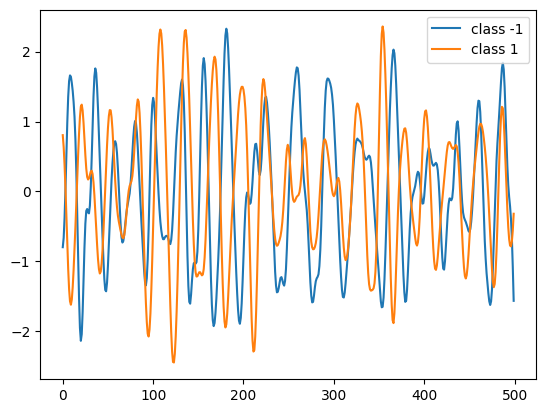

In [9]:
classes = torch.unique(torch.cat((y_train, y_test), dim=0))

plt.figure()
for c in classes:
    c_x_train = x_train[y_train == c]
    plt.plot(c_x_train[0].numpy(), label="class " + str(c.item()))
plt.legend()
plt.show()
plt.close()

## Standardize the data

Our timeseries are already in a single length (500). However, their values are
usually in various ranges. This is not ideal for a neural network;
in general we should seek to make the input values normalized.
For this specific dataset, the data is already z-normalized: each timeseries sample
has a mean equal to zero and a standard deviation equal to one.

Note that the timeseries data used here are univariate, meaning we only have one channel (feature)
per timeseries example.
We will therefore transform the timeseries into a multivariate one with one channel (feature)
using a simple reshaping via PyTorch.
This will allow us to construct a model that is easily applicable to multivariate time
series.

In [10]:
# Add channel dimension for PyTorch (batch_size, sequence_length, input_size)
x_train = x_train.unsqueeze(2)  # Add channel dimension
x_test = x_test.unsqueeze(2)    # Add channel dimension

In [11]:
x_train.shape

torch.Size([3601, 500, 1])

Finally, in order to use `CrossEntropyLoss`, we will have to count
the number of classes beforehand.

In [12]:
num_classes = len(torch.unique(y_train))
print(num_classes)

2


Standardize the labels to positive integers.
The expected labels will then be 0 and 1.

In [13]:
# Standardize the labels to positive integers.
# The expected labels will then be 0 and 1.
y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

## Dataset and Data Loaders

Now, let's create a Pytorch dataset from the tensors.

In [14]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)
# split the train set into train and validation
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])


We will then create Data Loaders from the dataset.

In [15]:
batch_size = 32

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
len(train_dataset)

2881

## Build a PyTorch LSTM model

We use a single RNN layer to capture the temporal information and return the hidden states at each timestep. We then feed these timesteps into the dense layers for classification.

Note that we set the `batch_first=True` to have the batch dimension first. The output shape is thus of 3D shape (batch, time-steps, hidden_size). We then apply a linear layer to every time step and finally use a final linear layer for classification.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.4):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 16)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, num_classes)

    def forward(self, x):

        x, _ = self.lstm(x)  # x shape = (batch, timesteps, features)
        # print(f'after lstm: {x.shape}')

        # Option 1: only take from output from last timestep
        # x = x[:, -1, :]    # x shape = (batch, hidden_dim)

        # Option 2: averaging over all the timesteps
        x = torch.mean(x, dim=1)  # x shape = (batch, hidden_dim)
        # print(f'after mean: {x.shape}')
        x = self.batch_norm(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)  # (batch, num_classes)

        return x

We can print out the model information such as the different layers, the output shape from each layer and also the number of parameters.

In [18]:
input_size = x_train.shape[2]
hidden_size = 32

model = LSTMClassifier(input_size, hidden_size, num_classes)

summary(model, input_size=(1, 500, 1))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMClassifier                           [1, 2]                    --
├─LSTM: 1-1                              [1, 500, 32]              4,480
├─BatchNorm1d: 1-2                       [1, 32]                   64
├─Linear: 1-3                            [1, 16]                   528
├─ReLU: 1-4                              [1, 16]                   --
├─Dropout: 1-5                           [1, 16]                   --
├─Linear: 1-6                            [1, 2]                    34
Total params: 5,106
Trainable params: 5,106
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.02
Estimated Total Size (MB): 0.15

## Train the PyTorch model

In [19]:
# model hyper-parameters
hidden_dim = 32
input_size = x_train.shape[2]


# Training parameters
epochs = 50
learning_rate = 1e-3

# Set device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

# Instantiate model and move to device
torch.manual_seed(42)
model = LSTMClassifier(input_size, hidden_dim, num_classes).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

Using device: mps


Let's start the training.

In [20]:
print("Starting training...")

# Training loop with early stopping
best_val_acc = 0
patience = 50
patience_counter = 0

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    count = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted = torch.argmax(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()

    # Evaluation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()

    # Calculate average losses and accuracies
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # store the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # # Save best model
        torch.save(model.state_dict(), 'best_model.pth')

print('Training completed!')


Starting training...
Epoch [10/50], Train Loss: 0.2929, Train Acc: 0.8771, Val Loss: 0.4122, Val Acc: 0.8417
Epoch [20/50], Train Loss: 0.2301, Train Acc: 0.9160, Val Loss: 0.4667, Val Acc: 0.8264
Epoch [30/50], Train Loss: 0.2134, Train Acc: 0.9226, Val Loss: 0.2004, Val Acc: 0.9264
Epoch [40/50], Train Loss: 0.1947, Train Acc: 0.9240, Val Loss: 0.3959, Val Acc: 0.8625
Epoch [50/50], Train Loss: 0.1758, Train Acc: 0.9382, Val Loss: 0.2054, Val Acc: 0.9125
Training completed!


What is the performance of the model in terms of accuracy? 

**Exercise 1**

In option 1, we are only using the last timestep of the output of the LSTM.  What do you observe about the model performance?
Try changing to option 2.  Explain the is the rationale of option 2. Compare the performance with option 1.

**Exercise 2** 

Try adding *Batch Normalization Layer* or *Layer Normalization layer* to the model.  Compare the results with the previous model.  
What do you think could have happened? 

## Evaluate PyTorch model on test data

In [21]:
# Load the best model
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate on test data
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        test_total += batch_y.size(0)
        test_correct += (predicted == batch_y).sum().item()

test_accuracy = test_correct / test_total
avg_test_loss = test_loss / len(test_loader)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {avg_test_loss:.4f}")

Test accuracy: 0.9402
Test loss: 0.1588


## Visualize training using matplotlib

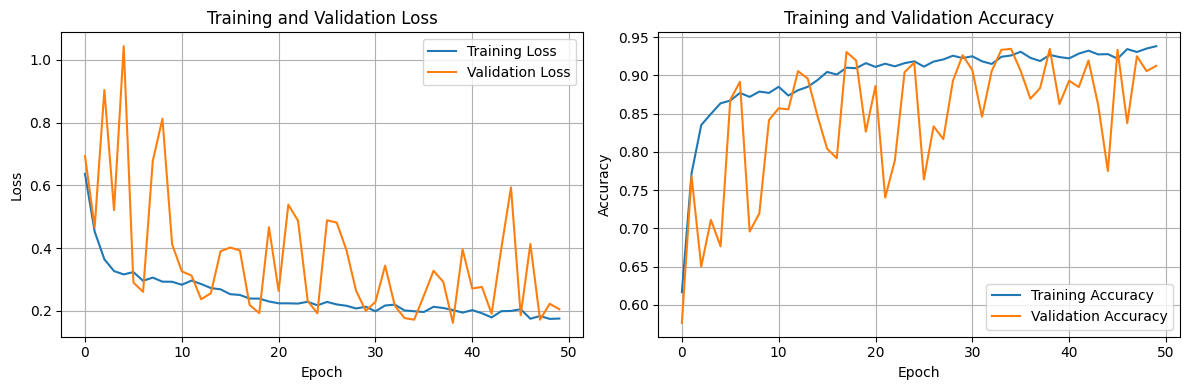

In [22]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracies
ax2.plot(train_accuracies, label='Training Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

We can see how that the validation accuracy is quite close to the training accuracy.